In [56]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

df = sns.load_dataset("mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [58]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [59]:
df.describe(include = "number")

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [60]:
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]
df[numeric_cols].describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000


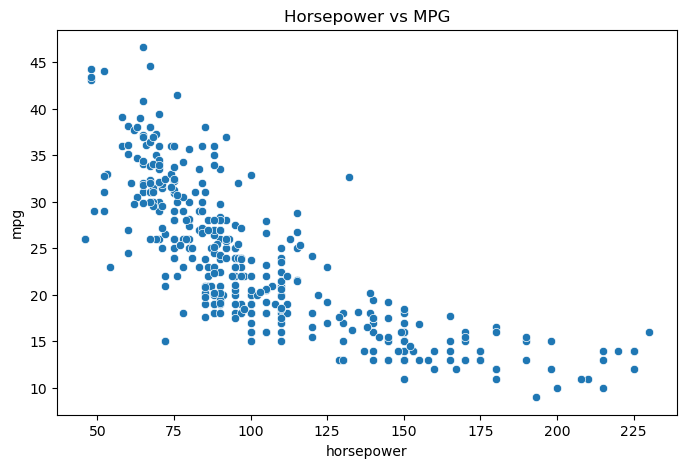

In [61]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = "horsepower", y = "mpg")
plt.title("Horsepower vs MPG")
plt.show()

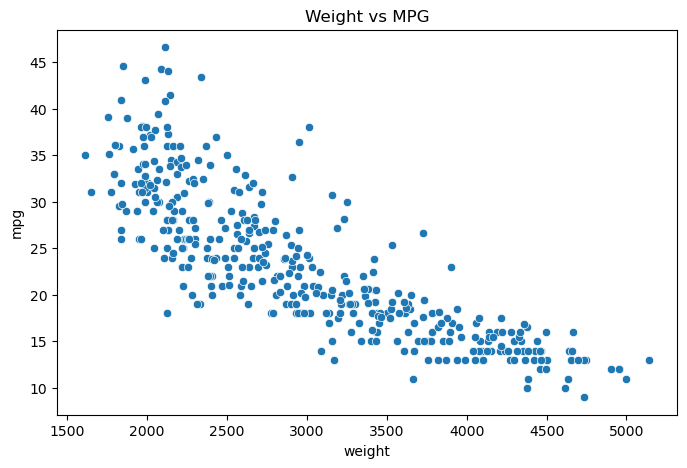

In [62]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = "weight", y = "mpg")
plt.title("Weight vs MPG")
plt.show()

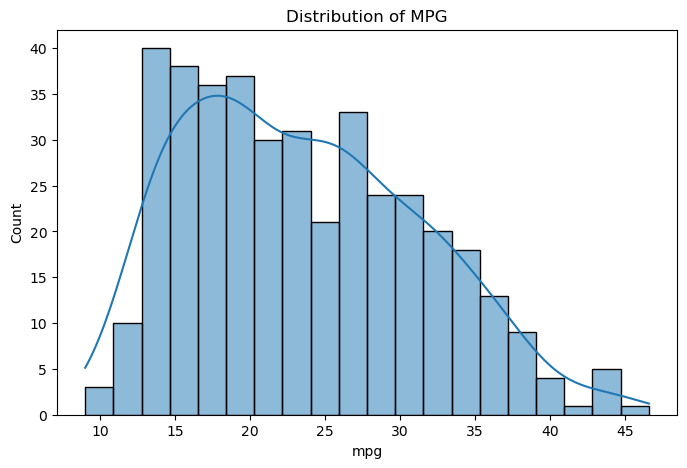

In [63]:
plt.figure(figsize = (8, 5))
sns.histplot(df["mpg"].dropna(), bins = 20, kde = True)
plt.title("Distribution of MPG")
plt.show()

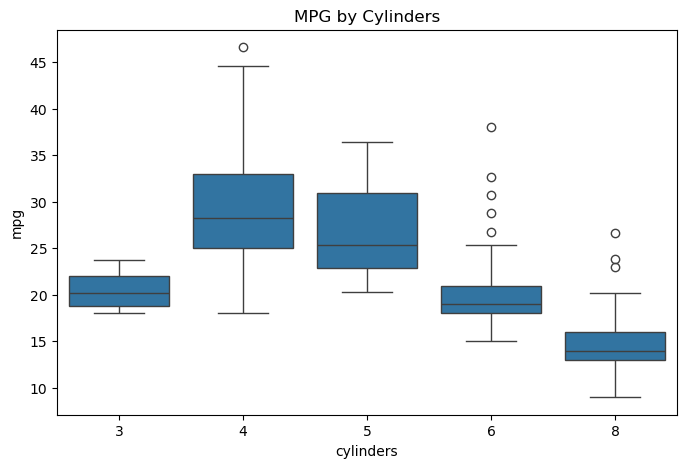

In [64]:
plt.figure(figsize = (8, 5))
sns.boxplot(data = df, x = "cylinders", y = "mpg")
plt.title("MPG by Cylinders")
plt.show()

In [65]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [66]:
df = df.dropna()
df = df.drop(columns = ["name", "origin"])
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [67]:
y = df["mpg"]
X = df.drop(columns = "mpg")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(313, 6)
(79, 6)
(313,)
(79,)


In [68]:
print(len(df))
print(len(df) * 0.8)
print(len(df) * 0.2)

392
313.6
78.4


In [69]:
def evaluate_regression_model(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")

    return mae, mse, rmse

model = LinearRegression()
evaluate_regression_model(X_train, X_test, y_train, y_test, model)

MAE: 2.50
MSE: 10.50
RMSE: 3.24


(2.5038600897761265, 10.502370329417312, np.float64(3.240736078334259))

In [70]:
def evaluate_model_to_dict(X_train, X_test, y_train, y_test, model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    return {
        "model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    }

In [71]:
models = {
    "Linear regression": LinearRegression(),

    "Linear regression scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("linear_regression", LinearRegression())
    ]),

    "Polynomial degree 1": Pipeline([
        ("poly", PolynomialFeatures(degree=1, include_bias=False)),
        ("linear_regression", LinearRegression())
    ]),

    "Polynomial degree 2": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("linear_regression", LinearRegression())
    ]),

    "Polynomial degree 3": Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("linear_regression", LinearRegression())
    ])
}

In [72]:
results = []

for name, model in models.items():
    results.append(
        evaluate_model_to_dict(X_train, X_test, y_train, y_test, model, name)
    )

results_df = pd.DataFrame(results)
results_df.sort_values("RMSE")

,model,MAE,MSE,RMSE
3,Polynomial degree 2,1.980477,7.419858,2.723942
4,Polynomial degree 3,2.037547,8.010491,2.830281
1,Linear regression scaled,2.503860,10.502370,3.240736
0,Linear regression,2.503860,10.502370,3.240736
2,Polynomial degree 1,2.503860,10.502370,3.240736


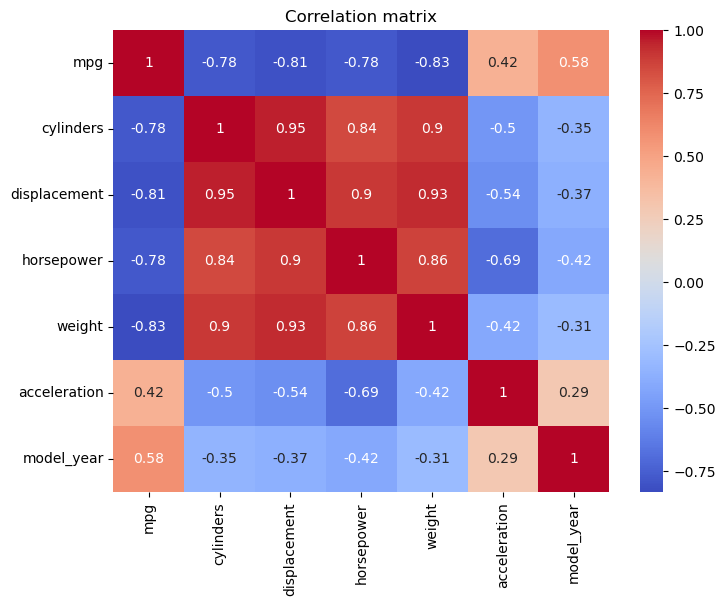

In [73]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()